# EDA và Preprocessing cho Vietnamese Sentiment Analysis với PhoBERT

- **Bài toán:** phân loại bình luận tiếng Việt thành 3 nhãn cảm xúc: **negative**, **neutral** và **positive**.

- **Mục tiêu notebook:** thực hiện EDA và preprocessing để chuẩn bị dữ liệu cho bước fine-tune mô hình **PhoBERT**.

- **Các nội dung chính:**
  - Kiểm tra cấu trúc dữ liệu, missing value, duplicate.
  - Phân tích phân phối nhãn.
  - Phân tích độ dài văn bản.
  - Kiểm tra nhiễu trong bình luận tiếng Việt.
  - Làm sạch văn bản ở mức vừa đủ.
  - Thực hiện word segmentation cho PhoBERT.
  - Chia train/validation/test theo stratify.
  - Kiểm tra độ dài sau PhoBERT tokenizer.
  - Tạo `DatasetDict` cho bước fine-tuning.

- **Định hướng preprocessing:** giữ lại tối đa tín hiệu cảm xúc trong tiếng Việt. Vì vậy, notebook không bỏ dấu tiếng Việt, không bỏ stopwords và không stemming.

- **Lý do:** các từ như “không”, “chưa”, “rất”, “quá” hoặc dấu câu như “!”, “?” có thể ảnh hưởng trực tiếp đến nhãn sentiment.

## 0. Import thư viện và cấu hình

In [1]:
# Nếu chạy trên Colab/Kaggle, mở comment các dòng dưới để cài thư viện cần thiết.
# !pip install -q pandas numpy matplotlib seaborn scipy scikit-learn underthesea transformers datasets

import os
import re
import html
import random
import unicodedata
import warnings
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from scipy.stats import kruskal
from sklearn.utils.class_weight import compute_class_weight
from underthesea import word_tokenize
from transformers import AutoTokenizer
from datasets import Dataset, DatasetDict

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 5)

DATA_PATH = "../data/raw/dulieu_huanluyen.csv"  # đổi path nếu chạy ở môi trường khác
SAVE_DIR = "../data/processed"
RANDOM_STATE = 42

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

[transformers] PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


## 1. Load dữ liệu và chuẩn hóa cấu trúc

Trước khi phân tích, dữ liệu được đưa về một cấu trúc thống nhất gồm hai cột chính: `text` là nội dung bình luận và `label` là nhãn cảm xúc. Việc chuẩn hóa tên cột giúp các bước phía sau dễ tái sử dụng hơn, đặc biệt khi chuyển từ EDA sang pipeline fine-tune PhoBERT.

In [2]:
raw_df = pd.read_csv(DATA_PATH)
print("Raw shape:", raw_df.shape)
display(raw_df.head())
print("Columns:", raw_df.columns.tolist())

TEXT_COL = "comments"
LABEL_COL = "flag"

label_map = {
    0: "negative",
    1: "neutral",
    2: "positive",
}

df = raw_df[[TEXT_COL, LABEL_COL]].copy()
df.columns = ["text", "label"]
df["text"] = df["text"].fillna("").astype(str)
df["label"] = df["label"].astype(int)
df["label_name"] = df["label"].map(label_map)

display(df.head())

Raw shape: (192986, 2)


,comments,flag
0,Mời hariwon đi ạ,1
1,Umie chỉ có tiếng thôi,1
2,Hix sân khấu hoàng tráng quay bằng drone khá đ...,1
3,Choáng quá camera ơi,1
4,Hay thì hây nhưng bớt quảng cáo lại được không,1


Columns: ['comments', 'flag']


,text,label,label_name
0,Mời hariwon đi ạ,1,neutral
1,Umie chỉ có tiếng thôi,1,neutral
2,Hix sân khấu hoàng tráng quay bằng drone khá đ...,1,neutral
3,Choáng quá camera ơi,1,neutral
4,Hay thì hây nhưng bớt quảng cáo lại được không,1,neutral


## 2. Tổng quan dữ liệu và phân phối nhãn

Phần này kiểm tra nhanh chất lượng dữ liệu ở mức cấu trúc: số lượng mẫu, missing text, bình luận rỗng, bản ghi trùng lặp và phân phối nhãn. Với bài toán phân loại cảm xúc ba lớp, phân phối nhãn là yếu tố quan trọng vì nó ảnh hưởng đến cách chia dữ liệu và cách diễn giải các metric như Accuracy, Macro-F1, Precision và Recall.

In [3]:
overview = pd.DataFrame({
    "num_rows": [len(df)],
    "num_columns": [df.shape[1]],
    "missing_text": [df["text"].isna().sum()],
    "empty_text": [(df["text"].str.strip() == "").sum()],
    "duplicate_text_raw": [df.duplicated(subset=["text"]).sum()],
    "num_labels": [df["label"].nunique()],
})

label_table = (
    df["label_name"]
    .value_counts()
    .rename_axis("label")
    .reset_index(name="count")
)
label_table["ratio"] = label_table["count"] / len(df)
label_table = label_table.sort_values("label")

display(overview)
display(label_table)

,num_rows,num_columns,missing_text,empty_text,duplicate_text_raw,num_labels
0,192986,3,0,0,6599,3


,label,count,ratio
2,negative,60716,0.314613
0,neutral,70424,0.364918
1,positive,61846,0.320469


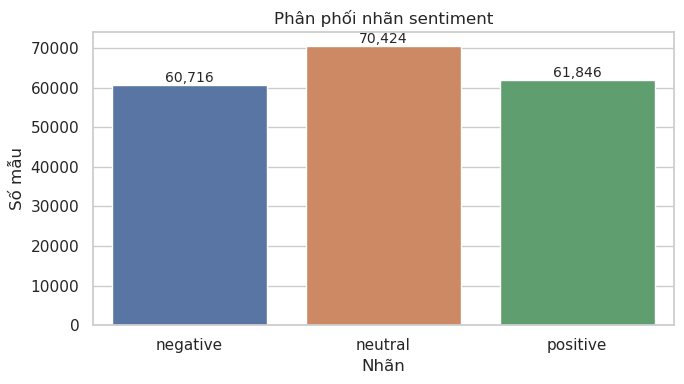

In [4]:
plt.figure(figsize=(7, 4))
ax = sns.barplot(data=label_table, x="label", y="count", hue="label", legend=False)
ax.set_title("Phân phối nhãn sentiment")
ax.set_xlabel("Nhãn")
ax.set_ylabel("Số mẫu")
for p in ax.patches:
    ax.annotate(f"{int(p.get_height()):,}",
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha="center", va="bottom", fontsize=10)
plt.tight_layout()
plt.show()

**Nhận xét**

Bộ dữ liệu gồm 192,986 mẫu và 3 cột, trong đó không có văn bản bị thiếu hoặc rỗng. Điều này cho thấy dữ liệu có cấu trúc khá đầy đủ, có thể sử dụng trực tiếp cho các bước phân tích và tiền xử lý tiếp theo. Tuy nhiên, tập dữ liệu có 6,599 văn bản bị trùng lặp, vì vậy cần xử lý duplicate trước khi chia train/validation/test để hạn chế rò rỉ dữ liệu giữa các tập.

Về phân phối nhãn, dữ liệu gồm 3 lớp cảm xúc: negative, neutral và positive. Lớp neutral có số lượng mẫu lớn nhất với 70,424 mẫu, chiếm khoảng 36.49% toàn bộ dữ liệu. Hai lớp còn lại có số lượng tương đối gần nhau: negative có 60,716 mẫu, chiếm khoảng 31.46%, và positive có 61,846 mẫu, chiếm khoảng 32.05%.

Nhìn chung, phân phối nhãn không bị lệch quá nghiêm trọng. Mặc dù lớp neutral chiếm tỷ lệ cao hơn hai lớp còn lại, mức chênh lệch giữa các lớp vẫn ở mức chấp nhận được cho bài toán phân loại cảm xúc 3 lớp. Do đó, khi huấn luyện PhoBERT, có thể sử dụng chiến lược chia dữ liệu phân tầng theo nhãn để đảm bảo train, validation và test giữ được tỷ lệ nhãn tương tự nhau. Ngoài ra, trong giai đoạn đánh giá mô hình, nên ưu tiên các chỉ số như Macro-F1, Precision, Recall bên cạnh Accuracy để phản ánh hiệu năng công bằng hơn trên cả ba lớp.

## 3. Phân tích độ dài văn bản

Độ dài bình luận ảnh hưởng trực tiếp đến chi phí huấn luyện PhoBERT. Bình luận quá dài có thể bị cắt khi tokenize, còn bình luận quá ngắn thường chứa ít ngữ cảnh và dễ gây nhầm lẫn giữa các lớp. Vì vậy, phần này phân tích số từ và số ký tự theo từng nhãn để làm cơ sở chọn `max_length` ở bước tokenizer.

### 3.1. Thống kê độ dài văn bản

Trước hết, ta tính số từ và số ký tự của từng bình luận ở trạng thái gốc. Các thống kê như trung bình, trung vị, phân vị 90%, 95% và 99% giúp mô tả độ dài phổ biến của dữ liệu, đồng thời tránh việc lựa chọn `max_length` chỉ dựa trên các văn bản ngoại lệ quá dài.

In [5]:
# Feature engineering độ dài văn bản gốc
df["num_words_raw"] = df["text"].str.split().str.len()
df["num_chars_raw"] = df["text"].str.len()

print("Thống kê độ dài toàn bộ corpus:")
display(
    df[["num_words_raw", "num_chars_raw"]]
    .describe(percentiles=[.5, .75, .9, .95, .99])
    .round(2)
)

# Thống kê độ dài theo nhãn
length_stats = (
    df.groupby("label_name")
    .agg(
        count=("text", "count"),
        words_mean=("num_words_raw", "mean"),
        words_median=("num_words_raw", "median"),
        words_std=("num_words_raw", "std"),
        words_q90=("num_words_raw", lambda s: s.quantile(0.90)),
        words_q95=("num_words_raw", lambda s: s.quantile(0.95)),
        words_q99=("num_words_raw", lambda s: s.quantile(0.99)),
        words_max=("num_words_raw", "max"),
        chars_mean=("num_chars_raw", "mean"),
        chars_median=("num_chars_raw", "median"),
    )
    .round(2)
)

display(length_stats)

Thống kê độ dài toàn bộ corpus:


,num_words_raw,num_chars_raw
count,192986.00,192986.00
mean,16.73,70.93
std,22.21,94.47
min,1.00,1.00
50%,11.00,45.00
75%,19.00,80.00
90%,34.00,146.00
95%,52.00,221.00
99%,109.00,464.00
max,943.00,3848.00


,count,words_mean,words_median,words_std,words_q90,words_q95,words_q99,words_max,chars_mean,chars_median
label_name,,,,,,,,,,
negative,60716,20.44,12.0,28.81,44.0,69.0,147.85,596,86.07,52.0
neutral,70424,14.15,9.0,17.38,29.0,42.0,82.00,943,59.68,39.0
positive,61846,16.01,10.0,18.92,32.0,46.0,100.00,391,68.87,45.0


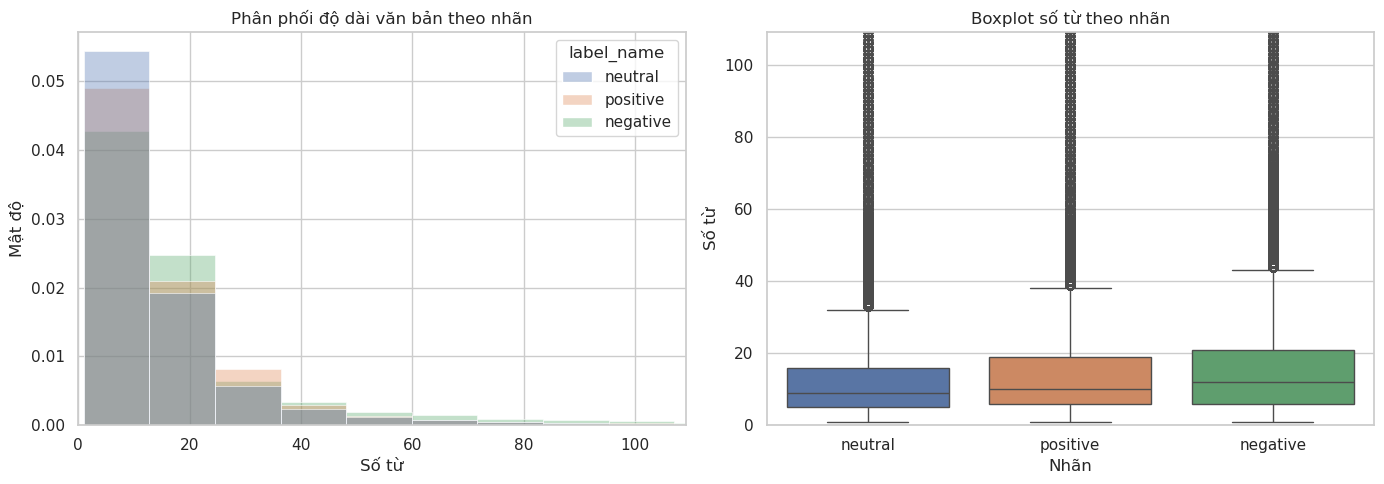

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

upper_len = df["num_words_raw"].quantile(0.99)

sns.histplot(
    data=df,
    x="num_words_raw",
    hue="label_name",
    bins=80,
    stat="density",
    common_norm=False,
    alpha=0.35,
    ax=axes[0],
)
axes[0].set_title("Phân phối độ dài văn bản theo nhãn")
axes[0].set_xlabel("Số từ")
axes[0].set_ylabel("Mật độ")
axes[0].set_xlim(0, upper_len)

sns.boxplot(
    data=df,
    x="label_name",
    y="num_words_raw",
    hue="label_name",
    legend=False,
    ax=axes[1],
)
axes[1].set_title("Boxplot số từ theo nhãn")
axes[1].set_xlabel("Nhãn")
axes[1].set_ylabel("Số từ")
axes[1].set_ylim(0, upper_len)

plt.tight_layout()
plt.show()

### 3.2. Kiểm định sự khác biệt độ dài giữa các lớp

Sau khi quan sát bảng thống kê và biểu đồ, có thể thấy độ dài bình luận giữa ba lớp sentiment có sự khác biệt nhất định, đặc biệt lớp negative có xu hướng dài hơn. Tuy nhiên, quan sát trực quan chưa đủ để kết luận sự khác biệt này có ý nghĩa thống kê hay không.

Vì bài toán có ba nhóm nhãn độc lập gồm negative, neutral và positive, đồng thời phân phối độ dài văn bản bị lệch phải và không đảm bảo giả định phân phối chuẩn, kiểm định Kruskal-Wallis được sử dụng thay cho ANOVA một chiều. Kiểm định này giúp đánh giá liệu phân phối độ dài của ít nhất một nhóm có khác biệt so với các nhóm còn lại hay không.

Cần lưu ý rằng kiểm định này chỉ đóng vai trò phân tích hỗ trợ trong EDA. Trong pipeline PhoBERT, độ dài văn bản không được dùng như một đặc trưng thủ công để huấn luyện mô hình, mà chủ yếu được dùng để hiểu dữ liệu, đánh giá sự khác biệt giữa các lớp và lựa chọn `MAX_LEN` phù hợp cho tokenizer.

In [7]:
# Kiểm định khác biệt độ dài giữa 3 lớp.
# Đây chỉ là phân tích hỗ trợ; độ dài không được dùng làm đặc trưng chính cho PhoBERT.
length_groups = [
    df.loc[df["label_name"] == lab, "num_words_raw"]
    for lab in sorted(df["label_name"].dropna().unique())
]
kw_stat, kw_p = kruskal(*length_groups)
length_test = pd.DataFrame({
    "test": ["Kruskal-Wallis"],
    "statistic": [kw_stat],
    "p_value": [kw_p],
})
display(length_test)

if kw_p < 0.05:
    print("Kết luận: Có sự khác biệt có ý nghĩa thống kê về phân phối độ dài giữa ít nhất hai lớp.")
else:
    print("Kết luận: Chưa đủ bằng chứng thống kê để kết luận phân phối độ dài khác nhau giữa các lớp.")

,test,statistic,p_value
0,Kruskal-Wallis,2333.075645,0.0


Kết luận: Có sự khác biệt có ý nghĩa thống kê về phân phối độ dài giữa ít nhất hai lớp.


**Nhận xét**

Bảng thống kê cho thấy các bình luận trong tập dữ liệu nhìn chung khá ngắn. Trung bình mỗi bình luận có khoảng 16.73 từ và 70.93 ký tự, trong khi trung vị chỉ là 11 từ và 45 ký tự. Sự chênh lệch giữa mean và median cho thấy phân phối độ dài bị lệch phải: đa số bình luận ngắn, nhưng vẫn tồn tại một số ít bình luận rất dài.

Các mốc phân vị cũng củng cố nhận xét này. Có 75% bình luận không quá 19 từ, 90% không quá 34 từ và 95% không quá 52 từ. Tuy nhiên, giá trị lớn nhất lên đến 943 từ, cao hơn rất nhiều so với phần lớn dữ liệu. Vì vậy, khi fine-tune PhoBERT, không nên chọn `MAX_LEN` dựa trên độ dài lớn nhất, vì điều này sẽ làm tăng padding và tốn tài nguyên huấn luyện. Thay vào đó, nên dựa trên các phân vị cao như 95% hoặc 99%, sau đó kiểm tra lại bằng tokenizer của PhoBERT.

Khi xét theo từng nhãn, lớp negative có độ dài trung bình cao nhất với 20.44 từ, tiếp theo là positive với 16.01 từ và neutral với 14.15 từ. Điều này cho thấy người dùng có xu hướng viết dài hơn khi thể hiện cảm xúc tiêu cực, có thể do họ cần mô tả chi tiết vấn đề hoặc lý do không hài lòng. Tuy nhiên, boxplot cho thấy ba lớp vẫn có vùng phân phối chồng lấn lớn, nên độ dài văn bản không đủ để tách biệt rõ ràng các lớp sentiment.

Biểu đồ histogram xác nhận rằng phần lớn bình luận tập trung ở vùng số từ thấp, trong khi phần đuôi kéo dài về bên phải do một số bình luận dài. Boxplot cũng cho thấy cả ba lớp đều có nhiều giá trị ngoại lệ ở phía trên, đặc biệt ở các bình luận dài hơn 40–50 từ.

Kết quả kiểm định Kruskal-Wallis cho p-value rất nhỏ, hiển thị gần bằng 0 do làm tròn, cho thấy có sự khác biệt có ý nghĩa thống kê về phân phối độ dài giữa ít nhất hai lớp sentiment. Tuy nhiên, do kích thước dữ liệu rất lớn, ngay cả khác biệt nhỏ cũng có thể trở nên có ý nghĩa thống kê. Vì vậy, kết quả kiểm định chỉ nên được xem là bằng chứng hỗ trợ cho EDA, không nên xem độ dài là đặc trưng phân loại chính.

Đối với pipeline PhoBERT, phân tích độ dài chủ yếu giúp lựa chọn `MAX_LEN`, đánh giá nguy cơ truncation và tối ưu chi phí huấn luyện. Mô hình vẫn nên học sentiment chủ yếu từ nội dung ngôn ngữ và ngữ cảnh của bình luận, thay vì dựa vào độ dài văn bản.

## 4. Kiểm tra nhiễu đặc trưng của bình luận tiếng Việt

Bình luận người dùng thường chứa URL, email, mention, hashtag, emoji, ký tự lặp và dấu câu nhấn mạnh. Không phải tất cả đều nên xóa. Với sentiment analysis, emoji và dấu câu có thể biểu diễn cảm xúc; hashtag có thể chứa từ khóa; còn URL hoặc email thường ít đóng góp trực tiếp cho nhãn. Vì vậy, bước này giúp quyết định loại nhiễu nào cần xử lý và loại tín hiệu nào nên giữ lại dưới dạng chuẩn hóa.

In [8]:
emoji_pattern = re.compile(
    "["
    "\U0001F600-\U0001F64F"  # emoticons
    "\U0001F300-\U0001F5FF"  # symbols & pictographs
    "\U0001F680-\U0001F6FF"  # transport & map symbols
    "\U0001F1E0-\U0001F1FF"  # flags
    "\U00002700-\U000027BF"
    "\U0001F900-\U0001F9FF"
    "]+",
    flags=re.UNICODE,
)

noise_report = pd.DataFrame({
    "metric": [
        "contains_url",
        "contains_email",
        "contains_mention",
        "contains_hashtag",
        "contains_digit",
        "contains_emoji",
        "contains_repeated_chars_3plus",
        "contains_exclamation",
        "contains_question",
    ],
    "count": [
        df["text"].str.contains(r"https?://|www\.", regex=True, case=False).sum(),
        df["text"].str.contains(r"\b[\w\.-]+@[\w\.-]+\.\w+\b", regex=True, case=False).sum(),
        df["text"].str.contains(r"@\w+", regex=True).sum(),
        df["text"].str.contains(r"#\w+", regex=True).sum(),
        df["text"].str.contains(r"\d", regex=True).sum(),
        df["text"].apply(lambda x: bool(emoji_pattern.search(x))).sum(),
        df["text"].str.contains(r"(.)\1{2,}", regex=True).sum(),
        df["text"].str.contains(r"!", regex=True).sum(),
        df["text"].str.contains(r"\?", regex=True).sum(),
    ],
})
noise_report["ratio"] = noise_report["count"] / len(df)
display(noise_report)

,metric,count,ratio
0,contains_url,0,0.000000
1,contains_email,0,0.000000
2,contains_mention,1,0.000005
3,contains_hashtag,1,0.000005
4,contains_digit,3037,0.015737
5,contains_emoji,4,0.000021
6,contains_repeated_chars_3plus,7129,0.036941
7,contains_exclamation,295,0.001529
8,contains_question,22,0.000114


**Nhận xét**

Bảng kiểm tra nhiễu cho thấy dữ liệu bình luận khá sạch về mặt cấu trúc. Hầu như không xuất hiện URL hoặc email trong văn bản, trong khi mention và hashtag chỉ xuất hiện 1 lần, chiếm tỷ lệ rất nhỏ. Điều này cho thấy các thành phần như URL, email, mention và hashtag không phải là nguồn nhiễu chính trong tập dữ liệu.

Một dạng nhiễu đáng chú ý hơn là ký tự lặp từ 3 lần trở lên, xuất hiện trong 7,129 bình luận, tương đương khoảng 3.69% dữ liệu. Đây là đặc trưng thường gặp trong bình luận người dùng, ví dụ như “đẹpppp”, “tệeee”, “quáaaa”, nhằm nhấn mạnh cảm xúc. Vì vậy, không nên xóa hoàn toàn hiện tượng này, mà nên rút gọn ký tự lặp để giảm nhiễu bề mặt nhưng vẫn giữ được sắc thái nhấn mạnh.

Các bình luận chứa chữ số chiếm khoảng 1.57%, có thể liên quan đến giá tiền, số lượng, kích thước, thời gian giao hàng hoặc mã sản phẩm. Do tỷ lệ này không quá cao và chữ số đôi khi vẫn mang thông tin ngữ cảnh, pipeline không cần xóa toàn bộ số mà có thể giữ lại hoặc chuẩn hóa tùy mục tiêu.

Emoji, dấu chấm than và dấu hỏi xuất hiện với tỷ lệ thấp. Tuy nhiên, trong bài toán sentiment analysis, các dấu hiệu này vẫn có thể mang thông tin cảm xúc, đặc biệt là dấu “!” hoặc emoji thể hiện hài lòng/không hài lòng. Vì vậy, pipeline nên xử lý theo hướng bảo toàn tín hiệu: emoji có thể được thay bằng token chung như `emoji`, còn các dấu câu cảm xúc như `!` và `?` nên được giữ lại.

Tổng thể, dữ liệu không chứa nhiều nhiễu định dạng nghiêm trọng. Do đó, chiến lược preprocessing phù hợp cho PhoBERT là làm sạch nhẹ: chuẩn hóa Unicode, thay URL/email/mention bằng token chung nếu có, giữ nội dung hashtag, rút gọn ký tự lặp và chuẩn hóa khoảng trắng. Không nên làm sạch quá mạnh vì có thể làm mất tín hiệu sentiment trong bình luận tiếng Việt.

## 5. Pipeline làm sạch văn bản phù hợp với PhoBERT

Pipeline dưới đây chỉ làm sạch ở mức cần thiết. Văn bản được chuẩn hóa Unicode, giải mã HTML, thay URL/email/mention bằng token chung, giữ nội dung hashtag, rút gọn ký tự lặp quá mức và chuẩn hóa khoảng trắng. Emoji không bị xóa hoàn toàn mà được thay bằng token `emoji` để mô hình vẫn nhận biết sự xuất hiện của tín hiệu cảm xúc.

Điểm quan trọng là không bỏ dấu tiếng Việt, không bỏ stopwords và không stemming. PhoBERT đã được tiền huấn luyện trên tiếng Việt, nên việc giữ cấu trúc ngôn ngữ tự nhiên thường phù hợp hơn so với làm sạch quá mạnh.

In [9]:
def normalize_unicode(text: str) -> str:
    return unicodedata.normalize("NFC", str(text))


def clean_text_for_phobert(text: str) -> str:
    text = normalize_unicode(text)
    text = html.unescape(text)
    text = re.sub(r"<[^>]+>", " ", text)

    # Chuẩn hóa các thành phần ít mang nội dung sentiment trực tiếp
    text = re.sub(r"https?://\S+|www\.\S+", " url ", text, flags=re.IGNORECASE)
    text = re.sub(r"\b[\w\.-]+@[\w\.-]+\.\w+\b", " email ", text, flags=re.IGNORECASE)
    text = re.sub(r"@\w+", " user ", text)

    # Giữ nội dung hashtag: #rat_tot -> rat_tot
    text = re.sub(r"#(\w+)", r" \1 ", text)

    # Giữ tín hiệu emoji ở dạng token chung
    text = emoji_pattern.sub(" emoji ", text)

    # Rút gọn ký tự lặp quá mức về tối đa 2 ký tự: đẹpppp -> đẹpp, quáaaaa -> quáa
    text = re.sub(r"(.)\1{2,}", r"\1\1", text)

    # Giữ chữ, số, khoảng trắng và một số dấu câu có thể mang cảm xúc
    text = re.sub(r"[^\w\s.!?,;:%+-]", " ", text, flags=re.UNICODE)

    # Chuẩn hóa khoảng trắng
    text = re.sub(r"\s+", " ", text).strip()
    return text


df["text_clean"] = df["text"].apply(clean_text_for_phobert)
df["num_words_clean"] = df["text_clean"].str.split().str.len()

display(df[["text", "text_clean", "label_name"]].sample(5, random_state=RANDOM_STATE))

clean_compare = pd.DataFrame({
    "version": ["raw", "clean"],
    "avg_words": [df["num_words_raw"].mean(), df["num_words_clean"].mean()],
    "median_words": [df["num_words_raw"].median(), df["num_words_clean"].median()],
    "empty_text": [(df["text"].str.strip() == "").sum(), (df["text_clean"].str.strip() == "").sum()],
    "duplicate_text": [df.duplicated("text").sum(), df.duplicated("text_clean").sum()],
}).round(2)

display(clean_compare)

,text,text_clean,label_name
70241,Hinh anh va video chi mang tinh chat minh hoa,Hinh anh va video chi mang tinh chat minh hoa,neutral
93867,hien tuong nay nam toi co đoc no trong qu...,hien tuong nay nam toi co đoc no trong quyen s...,positive
128137,áo len đẹp lắm lắm ý ạa mình mua có mấy nghìn...,áo len đẹp lắm lắm ý ạa mình mua có mấy nghìn ...,positive
118842,ok vs giá tuền Shop phục vụ rất tốt,ok vs giá tuền Shop phục vụ rất tốt,positive
171394,Vậy mà nói Apple Sam cũng cạn ý tưởng thiết k...,Vậy mà nói Apple Sam cũng cạn ý tưởng thiết kế...,negative


,version,avg_words,median_words,empty_text,duplicate_text
0,raw,16.73,11.0,0,6599
1,clean,16.72,11.0,0,9947


**Nhận xét**

Bảng ví dụ cho thấy pipeline làm sạch không làm thay đổi mạnh nội dung gốc của bình luận. Các câu sau khi xử lý vẫn giữ được phần lớn thông tin ngữ nghĩa, bao gồm từ tiếng Việt có dấu, từ phủ định, dấu câu và các cụm từ mang sắc thái cảm xúc. Điều này phù hợp với mục tiêu fine-tune PhoBERT, vì mô hình cần học ngữ cảnh tự nhiên của văn bản thay vì đầu vào bị chuẩn hóa quá mạnh.

So sánh giữa phiên bản `raw` và `clean` cho thấy độ dài trung bình gần như không thay đổi, từ 16.73 xuống 16.72 từ, và trung vị vẫn giữ ở mức 11 từ. Điều này chứng tỏ bước preprocessing chủ yếu xử lý nhiễu bề mặt như chuẩn hóa Unicode, ký tự đặc biệt, URL, mention, emoji hoặc ký tự lặp, chứ không làm mất nhiều nội dung văn bản.

Số lượng văn bản rỗng sau preprocessing vẫn bằng 0, nghĩa là pipeline không tạo ra mẫu rỗng mới. Đây là tín hiệu tốt vì không cần loại bỏ thêm nhiều dòng do mất nội dung sau khi làm sạch.

Tuy nhiên, số lượng văn bản trùng lặp tăng từ 6,599 ở dữ liệu raw lên 9,947 sau khi làm sạch. Điều này có thể xảy ra vì nhiều bình luận khác nhau ở bề mặt ký tự ban đầu trở thành giống nhau sau khi chuẩn hóa. Vì vậy, bước loại duplicate nên được thực hiện sau khi đã có văn bản sạch cuối cùng, đặc biệt là sau khi tạo `text_phobert`, để hạn chế rò rỉ dữ liệu giữa train, validation và test.

Nhìn chung, pipeline làm sạch hiện tại là phù hợp cho PhoBERT: xử lý các nhiễu không cần thiết nhưng vẫn giữ lại cấu trúc tiếng Việt và tín hiệu sentiment quan trọng. Sau bước này, dữ liệu có thể tiếp tục được word-segment để tạo đầu vào cuối cùng cho tokenizer PhoBERT.

## 6. Phân tích từ vựng và cụm từ sentiment sau khi làm sạch

Mục tiêu là kiểm tra xem dữ liệu có chứa các tín hiệu cảm xúc hợp lý hay không: token phổ biến, token thiên về từng lớp và một số cụm từ sentiment ngắn.

Các kết quả ở phần này giúp giải thích quyết định preprocessing: không bỏ dấu tiếng Việt, không xóa stopwords một cách máy móc, giữ từ phủ định như “không”, “chưa”, giữ từ tăng cường như “rất”, “quá”, và bảo toàn các cụm ngữ cảnh ngắn trước khi đưa vào PhoBERT.

### 6.1. Token phổ biến trong corpus và theo từng nhãn

Trước hết, ta đếm token sau bước làm sạch nhẹ. Việc này giúp phát hiện các từ quá phổ biến, các token nhiễu còn sót lại và các từ có khả năng gắn với từng nhóm cảm xúc.

In [10]:
def simple_tokens(text: str):
    return str(text).lower().split()


df["tokens_clean"] = df["text_clean"].apply(simple_tokens)

counter_all = Counter(tok for toks in df["tokens_clean"] for tok in toks)
counter_by_label = {
    lab: Counter(tok for toks in df.loc[df["label_name"] == lab, "tokens_clean"] for tok in toks)
    for lab in sorted(df["label_name"].dropna().unique())
}

print("Top token toàn bộ corpus")
display(pd.DataFrame(counter_all.most_common(25), columns=["token", "freq"]))

for lab, counter in counter_by_label.items():
    print(f"\nTop token - {lab}")
    display(pd.DataFrame(counter.most_common(20), columns=["token", "freq"]))

Top token toàn bộ corpus


,token,freq
0,co,22331
1,cho,20653
2,có,20510
3,là,19551
4,k,18549
5,ko,18419
6,la,18290
7,mình,18030
8,không,18029
9,rất,17661



Top token - negative


,token,freq
0,khong,10442
1,không,10283
2,co,9808
3,k,9440
4,cho,9354
5,ko,9134
6,thi,8248
7,con,8127
8,có,7944
9,la,7940



Top token - neutral


,token,freq
0,co,8737
1,la,7203
2,cho,7032
3,có,6844
4,thi,6760
5,ko,6444
6,là,6413
7,con,5980
8,đi,5912
9,k,5470



Top token - positive


,token,freq
0,rất,13411
1,shop,12494
2,rat,11117
3,đẹp,9475
4,đep,9112
5,giao,8314
6,nhanh,7811
7,chất,7068
8,và,7001
9,hàng,6918


**Nhận xét**

Bảng top token cho thấy dữ liệu có nhiều từ chức năng và từ viết tắt thường gặp trong bình luận tiếng Việt như “co”, “có”, “k”, “ko”, “không”, “khong”, “mình”, “minh”, “thì”, “thi”. Điều này phản ánh đặc trưng của dữ liệu người dùng tạo ra, trong đó tồn tại song song cả tiếng Việt có dấu, không dấu và cách viết tắt. Vì vậy, preprocessing không nên tự động xóa các token này, đặc biệt là nhóm phủ định như “không”, “khong”, “k”, “ko”, vì chúng có ảnh hưởng trực tiếp đến ý nghĩa sentiment.

Khi xét theo từng nhãn, lớp negative có tần suất cao của các token phủ định như “khong”, “không”, “k”, “ko”. Đây là tín hiệu hợp lý vì các bình luận tiêu cực thường chứa cấu trúc phủ định hoặc phản ánh sự không hài lòng. Lớp positive nổi bật với các token như “rất”, “rat”, “shop”, “đẹp”, “đep”, “giao”, “nhanh”, “chất”, “hàng”, “sản”, “phẩm”, cho thấy nhiều bình luận tích cực liên quan đến đánh giá sản phẩm, chất lượng và trải nghiệm giao hàng. Lớp neutral chứa nhiều token phổ biến chung như “co”, “la”, “cho”, “thi”, “con”, nên mang tính mô tả hoặc trung tính hơn.

Một điểm đáng chú ý là nhiều cặp từ có dấu và không dấu cùng xuất hiện với tần suất cao, ví dụ “có/co”, “là/la”, “rất/rat”, “không/khong”, “đẹp/đep”. Điều này cho thấy dữ liệu chưa hoàn toàn đồng nhất về chuẩn chính tả. Tuy nhiên, vì PhoBERT được huấn luyện trên tiếng Việt tự nhiên và có tokenizer subword, ta không nhất thiết phải ép khôi phục dấu hoặc chuẩn hóa quá mạnh. Thay vào đó, nên giữ văn bản gần với cách người dùng viết thật, chỉ xử lý các nhiễu bề mặt và thực hiện word segmentation trước khi đưa vào PhoBERT.

Tóm lại, phân tích top token xác nhận rằng dữ liệu có các tín hiệu sentiment rõ ràng, đặc biệt ở lớp negative và positive. Kết quả này củng cố lựa chọn preprocessing nhẹ: giữ từ phủ định, giữ từ tăng cường cảm xúc, không bỏ stopwords hàng loạt và không stemming/lemmatization.

### 6.2. Token thiên về từng lớp sentiment

Chỉ nhìn token phổ biến có thể bị chi phối bởi các từ xuất hiện nhiều ở mọi lớp. Vì vậy, ta dùng log-ratio có làm trơn để tìm các token xuất hiện tương đối nhiều hơn ở một lớp so với hai lớp còn lại. Phân tích này giúp kiểm tra dữ liệu có tín hiệu cảm xúc phân biệt giữa negative, neutral và positive hay không.

In [11]:
# Log-ratio: mỗi lớp so với phần còn lại
# Mục tiêu: tìm các token xuất hiện tương đối nhiều hơn ở một lớp sentiment
# so với hai lớp còn lại. Kết quả chỉ dùng để hiểu dữ liệu, không dùng làm
# đặc trưng thủ công cho PhoBERT.

labels_sorted = sorted(df["label_name"].dropna().unique())
vocab = set(counter_all.keys())
vocab_size = len(vocab)

MIN_TOTAL_FREQ = 100   # token phải xuất hiện đủ nhiều trong toàn corpus
MIN_TARGET_FREQ = 50   # token phải xuất hiện đủ nhiều trong lớp đang xét

rows = []

for target_lab in labels_sorted:
    target_counter = counter_by_label[target_lab]
    other_counter = Counter()

    for lab, c in counter_by_label.items():
        if lab != target_lab:
            other_counter.update(c)

    total_target = sum(target_counter.values())
    total_other = sum(other_counter.values())

    for tok in vocab:
        freq_target = target_counter[tok]
        freq_other = other_counter[tok]
        total_freq = freq_target + freq_other

        clean_tok = tok.strip(".,!?;:%+-_")

        # Bỏ token quá hiếm
        if total_freq < MIN_TOTAL_FREQ:
            continue

        # Bỏ token xuất hiện quá ít trong lớp mục tiêu
        if freq_target < MIN_TARGET_FREQ:
            continue

        # Bỏ token quá ngắn
        if len(clean_tok) < 2:
            continue

        # Bỏ token toàn số, ví dụ: 10, 00, 100
        if clean_tok.isdigit():
            continue

        # Bỏ token chỉ gồm ký tự đặc biệt sau khi strip
        if clean_tok == "":
            continue

        log2_ratio = np.log2(
            ((freq_target + 1) / (total_target + vocab_size)) /
            ((freq_other + 1) / (total_other + vocab_size))
        )

        rows.append({
            "label": target_lab,
            "token": tok,
            "freq_target": freq_target,
            "freq_other": freq_other,
            "total_freq": total_freq,
            "log2_ratio": log2_ratio,
        })

logratio_df = pd.DataFrame(rows)

for lab in labels_sorted:
    print(f"\nToken thiên về lớp {lab}")
    display(
        logratio_df[logratio_df["label"] == lab]
        .sort_values("log2_ratio", ascending=False)
        .head(15)
        .reset_index(drop=True)
    )


Token thiên về lớp negative


,label,token,freq_target,freq_other,total_freq,log2_ratio
0,negative,loz,142,0,142,7.825169
1,negative,dỡ,493,13,506,5.806310
2,negative,xàm,418,15,433,5.376104
3,negative,sony,230,8,238,5.347122
4,negative,xạo,123,4,127,5.297566
5,negative,tệ,1866,81,1947,5.174252
6,negative,lồn,278,12,290,5.088979
7,negative,android,100,4,104,5.001581
8,negative,thiu,96,5,101,4.680248
9,negative,đm,354,22,376,4.613411



Token thiên về lớp neutral


,label,token,freq_target,freq_other,total_freq,log2_ratio
0,neutral,drama,186,28,214,3.826589
1,neutral,ash,106,18,124,3.631215
2,neutral,island,106,18,124,3.631215
3,neutral,minamino,151,26,177,3.630715
4,neutral,jong,86,16,102,3.493156
5,neutral,trấn,428,87,515,3.423077
6,neutral,hóng,207,44,251,3.346262
7,neutral,quynh,113,24,137,3.326709
8,neutral,liver,102,22,124,3.300614
9,neutral,andree,150,34,184,3.246797



Token thiên về lớp positive


,label,token,freq_target,freq_other,total_freq,log2_ratio
0,positive,xinhh,117,2,119,6.447866
1,positive,vời,3284,148,3432,5.612694
2,positive,romand,186,10,196,5.237648
3,positive,hayy,128,7,135,5.161413
4,positive,tuyệt,3776,277,4053,4.914269
5,positive,mlbb,176,14,190,4.710900
6,positive,tone,147,12,159,4.659199
7,positive,tuyet,3529,326,3855,4.582491
8,positive,xinh,2663,267,2930,4.463474
9,positive,ngậy,176,22,198,4.094229


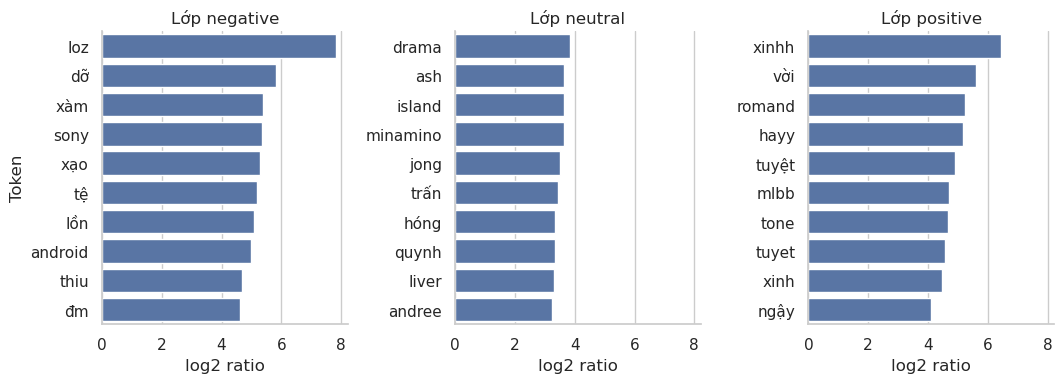

In [12]:
# Biểu đồ top token phân biệt nhất theo từng lớp

plot_rows = []
top_k = 10

for lab in labels_sorted:
    tmp = (
        logratio_df[logratio_df["label"] == lab]
        .sort_values("log2_ratio", ascending=False)
        .head(top_k)
        .copy()
    )
    plot_rows.append(tmp)

plot_logratio = pd.concat(plot_rows, ignore_index=True)

g = sns.catplot(
    data=plot_logratio,
    y="token",
    x="log2_ratio",
    col="label",
    kind="bar",
    sharey=False,
    height=4,
    aspect=0.9,
)

g.set_titles("Lớp {col_name}")
g.set_axis_labels("log2 ratio", "Token")

plt.tight_layout()
plt.show()

**Nhận xét**

Kết quả log-ratio cho thấy các token thiên về từng lớp có sự khác biệt khá rõ. Ở lớp negative, nhiều token mang sắc thái tiêu cực hoặc phàn nàn xuất hiện nổi bật như “dỡ”, “xàm”, “xạo”, “tệ”, “tởm” và một số từ cảm thán mạnh. Điều này phù hợp với đặc trưng của các bình luận không hài lòng, trong đó người dùng thường sử dụng từ chê bai hoặc ngôn ngữ nhấn mạnh cảm xúc tiêu cực.

Ở lớp positive, các token có log-ratio cao thể hiện sắc thái khen ngợi rõ hơn, ví dụ “vời”, “tuyệt”, “tuyet”, “xinh”, “đỉnh”, “ưng”. Đây là các từ thường xuất hiện trong bình luận đánh giá tích cực về sản phẩm, chất lượng hoặc trải nghiệm mua hàng. Ngoài ra, một số token như “romand”, “mlbb”, “tone” cho thấy dữ liệu có thể chứa các bình luận liên quan đến sản phẩm làm đẹp hoặc mỹ phẩm, trong đó cảm xúc tích cực gắn với đặc điểm sản phẩm cụ thể.

Đối với lớp neutral, các token nổi bật như “drama”, “hóng”, “trấn”, “rapper”, “karik”, “real” mang tính chủ đề hoặc tên riêng nhiều hơn là cảm xúc trực tiếp. Điều này cho thấy lớp neutral có xu hướng chứa các bình luận mang tính thảo luận, nhắc đến sự kiện, nhân vật hoặc nội dung cụ thể thay vì thể hiện thái độ tích cực/tiêu cực rõ ràng. Đây cũng là lý do lớp neutral thường khó phân biệt hơn trong bài toán sentiment analysis.

Biểu đồ log-ratio giúp trực quan hóa các token có tính phân biệt tương đối giữa các lớp. Tuy nhiên, cần lưu ý rằng log-ratio vẫn có thể làm nổi bật một số token đặc thù của miền dữ liệu, tên sản phẩm, tên riêng hoặc từ lóng. Vì vậy, kết quả này chỉ được dùng để hiểu đặc điểm ngôn ngữ của dữ liệu và kiểm tra tín hiệu sentiment, không dùng trực tiếp làm đặc trưng thủ công cho PhoBERT. Với mô hình PhoBERT, mục tiêu là giữ lại các token và ngữ cảnh này trong văn bản đầu vào để mô hình tự học mối quan hệ giữa nội dung bình luận và nhãn cảm xúc.

### 6.3. Bigram và một số cụm từ sentiment quan trọng

Trong sentiment analysis, ý nghĩa cảm xúc thường nằm ở cụm từ chứ không chỉ ở từng từ đơn. Ví dụ “không tốt” khác với “tốt”, hoặc “rất hài lòng” mạnh hơn “hài lòng”. Vì vậy, phần này kiểm tra một số bigram và cụm từ thường gặp trong bình luận tiếng Việt.

In [13]:
def build_bigram_counter(token_series):
    counter = Counter()
    for toks in token_series:
        if len(toks) >= 2:
            counter.update(" ".join([toks[i], toks[i + 1]]) for i in range(len(toks) - 1))
    return counter


bigram_by_label = {
    lab: build_bigram_counter(df.loc[df["label_name"] == lab, "tokens_clean"])
    for lab in labels_sorted
}

for lab, counter in bigram_by_label.items():
    print(f"\nTop bigram - {lab}")
    display(pd.DataFrame(counter.most_common(15), columns=["bigram", "freq"]))

# Một số cụm từ thường có ý nghĩa sentiment trong tiếng Việt
probe_phrases = [
    "không tốt",
    "không đẹp",
    "không hài lòng",
    "không thích",
    "không nên",
    "thất vọng",
    "quá tệ",
    "rất tốt",
    "rất đẹp",
    "tuyệt vời",
    "hài lòng",
    "giao hàng nhanh",
    "sản phẩm tốt",
    "bình thường",
    "tạm ổn",
]

phrase_rows = []
for phrase in probe_phrases:
    row = {"phrase": phrase}
    for lab in labels_sorted:
        row[lab] = (
            df.loc[df["label_name"] == lab, "text_clean"]
            .str.lower()
            .str.contains(re.escape(phrase), regex=True)
            .sum()
        )
    phrase_rows.append(row)

phrase_df = pd.DataFrame(phrase_rows)
display(phrase_df)


Top bigram - negative


,bigram,freq
0,anh ta,1574
1,chat luong,1255
2,chất lượng,1217
3,nhan vien,1186
4,phuc vu,1183
5,nhân viên,1167
6,phục vụ,1161
7,khong co,1017
8,không có,1003
9,cam thay,974



Top bigram - neutral


,bigram,freq
0,san pham,931
1,sản phẩm,882
2,giao hang,834
3,giao hàng,812
4,chat luong,760
5,chất lượng,719
6,chuong trinh,596
7,chương trình,566
8,tran thanh,502
9,hang nhanh,455



Top bigram - positive


,bigram,freq
0,san pham,6373
1,sản phẩm,6268
2,chất lượng,4761
3,chat luong,4375
4,giao hang,3458
5,giao hàng,3414
6,tuyệt vời,3248
7,gian giao,3181
8,tuyet voi,3131
9,luong san,3116


,phrase,negative,neutral,positive
0,không tốt,105,12,4
1,không đẹp,187,29,18
2,không hài lòng,75,10,4
3,không thích,348,31,60
4,không nên,61,40,19
5,thất vọng,914,50,76
6,quá tệ,347,4,0
7,rất tốt,23,85,1366
8,rất đẹp,51,111,2250
9,tuyệt vời,43,100,2950


**Nhận xét**

Kết quả bigram cho thấy nhiều cụm từ phổ biến phản ánh đúng đặc trưng của dữ liệu bình luận tiếng Việt. Ở cả ba lớp đều xuất hiện các cụm như “sản phẩm”, “chất lượng”, “giao hàng”, cho thấy dữ liệu có nhiều nội dung liên quan đến đánh giá sản phẩm và trải nghiệm mua hàng. Tuy nhiên, ý nghĩa sentiment không chỉ nằm ở bản thân các cụm này, mà phụ thuộc vào ngữ cảnh đi kèm.

Ở lớp negative, các bigram như “không có”, “cảm thấy”, “thất vọng”, cùng các cụm liên quan đến “nhân viên”, “phục vụ”, “chất lượng” cho thấy bình luận tiêu cực thường gắn với trải nghiệm không hài lòng về sản phẩm hoặc dịch vụ. Đặc biệt, cụm “thất vọng” xuất hiện nhiều ở lớp negative, phù hợp với trực giác của bài toán sentiment analysis.

Ở lớp positive, các bigram nổi bật như “tuyệt vời”, “tuyet voi”, “đóng gói”, “sản phẩm”, “chất lượng”, “giao hàng” cho thấy bình luận tích cực thường tập trung vào chất lượng sản phẩm, tốc độ giao hàng và trải nghiệm mua hàng tốt. Việc cả dạng có dấu và không dấu cùng xuất hiện, ví dụ “tuyệt vời” và “tuyet voi”, tiếp tục cho thấy dữ liệu mang đặc trưng bình luận người dùng thực tế.

Bảng cụm từ sentiment củng cố rõ hơn sự khác biệt giữa các lớp. Các cụm tiêu cực như “không tốt”, “không đẹp”, “không hài lòng”, “thất vọng”, “quá tệ” tập trung chủ yếu ở lớp negative. Ngược lại, các cụm tích cực như “rất tốt”, “rất đẹp”, “tuyệt vời”, “giao hàng nhanh”, “sản phẩm tốt” xuất hiện nhiều hơn ở lớp positive. Lớp neutral có một số cụm liên quan đến mô tả hoặc trải nghiệm trung tính, nhưng nhìn chung không mang cảm xúc mạnh bằng hai lớp còn lại.

Kết quả này cho thấy sentiment trong dữ liệu không chỉ phụ thuộc vào từng từ đơn, mà còn phụ thuộc nhiều vào cụm từ và ngữ cảnh ngắn, đặc biệt là các cấu trúc phủ định như “không tốt”, “không đẹp” hoặc các cụm khen ngợi như “rất đẹp”, “tuyệt vời”. Vì vậy, pipeline preprocessing không nên xóa từ phủ định, không bỏ stopwords một cách máy móc và không chuẩn hóa quá mạnh. Với PhoBERT, các cụm từ này nên được giữ lại trong văn bản đầu vào để mô hình học quan hệ ngữ cảnh khi fine-tune.

## 7. Word segmentation cho PhoBERT

PhoBERT được tiền huấn luyện trên dữ liệu tiếng Việt đã được tách từ. Vì vậy, trước khi đưa văn bản vào tokenizer của PhoBERT, câu tiếng Việt nên được word-segment để các từ ghép như “sản phẩm”, “giao hàng”, “hài lòng” được biểu diễn ổn định hơn. Trong notebook này, `underthesea` được dùng để tạo cột `text_phobert`.

In [14]:
def word_segment_vi(text: str) -> str:
    text = str(text).strip()
    if not text:
        return ""
    return word_tokenize(text, format="text")


df["text_phobert"] = df["text_clean"].apply(word_segment_vi)

display(df[["text_clean", "text_phobert", "label_name"]].sample(5, random_state=RANDOM_STATE))

,text_clean,text_phobert,label_name
70241,Hinh anh va video chi mang tinh chat minh hoa,Hinh anh va_video chi mang tinh chat_minh hoa,neutral
93867,hien tuong nay nam toi co đoc no trong quyen s...,hien tuong nay nam_toi co_đoc no trong quyen s...,positive
128137,áo len đẹp lắm lắm ý ạa mình mua có mấy nghìn ...,áo len_đẹp lắm lắm_ý ạa mình mua có mấy nghìn ...,positive
118842,ok vs giá tuền Shop phục vụ rất tốt,ok vs giá tuền_Shop phục_vụ rất tốt,positive
171394,Vậy mà nói Apple Sam cũng cạn ý tưởng thiết kế...,Vậy_mà nói Apple_Sam cũng cạn ý_tưởng thiết_kế...,negative


**Nhận xét**

Kết quả word segmentation cho thấy các từ ghép tiếng Việt được nối bằng dấu gạch dưới, ví dụ “minh hoa” thành “minh_hoa”, “phục vụ” thành “phục_vụ”, hoặc “ý tưởng” thành “ý_tưởng”. Đây là định dạng phù hợp khi sử dụng PhoBERT, vì mô hình này được tiền huấn luyện trên dữ liệu tiếng Việt đã được tách từ.

Việc tạo cột `text_phobert` giúp tách rõ hai phiên bản dữ liệu: `text_clean` là văn bản đã được làm sạch nhẹ, còn `text_phobert` là đầu vào cuối cùng dùng cho tokenizer PhoBERT. Các bước chia train/validation/test và encode bằng tokenizer nên sử dụng cột `text_phobert` để đảm bảo dữ liệu đầu vào nhất quán với mô hình.

Nhìn chung, bước word segmentation không làm mất nội dung bình luận mà chỉ chuẩn hóa cách biểu diễn từ tiếng Việt. Điều này đặc biệt hữu ích với các cụm từ như “sản phẩm”, “giao hàng”, “hài lòng”, “phục vụ”, vì đây là những cụm có thể mang thông tin sentiment quan trọng trong bài toán phân loại cảm xúc.

## 8. Loại trùng và chia train/validation/test

Sau khi có văn bản cuối cùng cho PhoBERT, dữ liệu được làm sạch duplicate và chia thành ba tập. Việc chia theo `stratify` giúp giữ tỷ lệ nhãn tương đối ổn định giữa train, validation và test. Tập validation dùng để chọn hyperparameter hoặc early stopping, còn tập test chỉ dùng để đánh giá cuối cùng.

In [15]:
# Loại các dòng rỗng sau preprocessing/segmentation
df_model = df[df["text_phobert"].str.strip() != ""].copy()

# Nếu cùng một text sau preprocessing có nhiều nhãn khác nhau, đây là trường hợp mơ hồ.
# Loại các text mơ hồ giúp giảm nhiễu nhãn và tránh rò rỉ khi chia tập.
label_nunique = df_model.groupby("text_phobert")["label"].nunique()
ambiguous_texts = set(label_nunique[label_nunique > 1].index)
print("Số text có nhiều hơn một nhãn:", len(ambiguous_texts))

if len(ambiguous_texts) > 0:
    df_model = df_model[~df_model["text_phobert"].isin(ambiguous_texts)].copy()

# Loại duplicate theo input cuối cùng của PhoBERT
df_model = df_model.drop_duplicates(subset=["text_phobert"]).reset_index(drop=True)

print("Shape sau khi làm sạch cho modeling:", df_model.shape)
display(df_model["label_name"].value_counts(normalize=True).rename("ratio").to_frame())

# Split 70/15/15
train_df, temp_df = train_test_split(
    df_model,
    test_size=0.30,
    stratify=df_model["label"],
    random_state=RANDOM_STATE,
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=RANDOM_STATE,
)

for name, subset in [("train", train_df), ("validation", val_df), ("test", test_df)]:
    print(f"\n{name}: {subset.shape}")
    display(subset["label_name"].value_counts(normalize=True).sort_index().rename("ratio").to_frame())

# Kiểm tra không có overlap text giữa các tập
train_texts = set(train_df["text_phobert"])
val_texts = set(val_df["text_phobert"])
test_texts = set(test_df["text_phobert"])
print("Overlap train-val:", len(train_texts & val_texts))
print("Overlap train-test:", len(train_texts & test_texts))
print("Overlap val-test:", len(val_texts & test_texts))

Số text có nhiều hơn một nhãn: 836
Shape sau khi làm sạch cho modeling: (182195, 9)


,ratio
label_name,
neutral,0.360581
positive,0.326820
negative,0.312599



train: (127536, 9)


,ratio
label_name,
negative,0.312602
neutral,0.360581
positive,0.326818



validation: (27329, 9)


,ratio
label_name,
negative,0.312598
neutral,0.360569
positive,0.326832



test: (27330, 9)


,ratio
label_name,
negative,0.312587
neutral,0.360593
positive,0.326820


Overlap train-val: 0
Overlap train-test: 0
Overlap val-test: 0


In [16]:
# Lưu các file đã sẵn sàng cho PhoBERT
os.makedirs(SAVE_DIR, exist_ok=True)
cols_to_save = ["text_phobert", "label", "label_name"]
train_path = os.path.join(SAVE_DIR, "train_phobert_merged.csv")
val_path = os.path.join(SAVE_DIR, "val_phobert_merged.csv")
test_path = os.path.join(SAVE_DIR, "test_phobert_merged.csv")
all_path = os.path.join(SAVE_DIR, "all_phobert_merged.csv")

train_df[cols_to_save].to_csv(train_path, index=False, encoding="utf-8-sig")
val_df[cols_to_save].to_csv(val_path, index=False, encoding="utf-8-sig")
test_df[cols_to_save].to_csv(test_path, index=False, encoding="utf-8-sig")
df_model[cols_to_save].to_csv(all_path, index=False, encoding="utf-8-sig")

print(train_path)
print(val_path)
print(test_path)
print(all_path)

../data/processed/train_phobert_merged.csv
../data/processed/val_phobert_merged.csv
../data/processed/test_phobert_merged.csv
../data/processed/all_phobert_merged.csv


**Nhận xét**

Sau khi loại các văn bản rỗng, các văn bản có nhiều hơn một nhãn và các bản ghi trùng lặp theo `text_phobert`, tập dữ liệu còn 182,195 mẫu. Có 836 văn bản xuất hiện với nhiều hơn một nhãn; đây là các trường hợp mơ hồ về nhãn nên được loại bỏ để giảm nhiễu khi huấn luyện.

Tỷ lệ nhãn sau khi làm sạch vẫn tương đối ổn định, với neutral khoảng 36.06%, positive khoảng 32.68% và negative khoảng 31.26%. Các tập train, validation và test cũng giữ gần như đúng tỷ lệ này nhờ sử dụng stratified split. Ngoài ra, overlap giữa các tập đều bằng 0, cho thấy không có cùng một văn bản xuất hiện đồng thời ở nhiều tập. Điều này giúp hạn chế rò rỉ dữ liệu và làm cho kết quả đánh giá mô hình đáng tin cậy hơn.

## 9. Kiểm tra độ dài với tokenizer PhoBERT

Số từ sau word segmentation chưa hoàn toàn giống số token mà PhoBERT xử lý. Tokenizer có thể tiếp tục tách một số từ thành subword, vì vậy cần đo lại độ dài bằng tokenizer `vinai/phobert-base`. Kết quả ở đây dùng để chọn `MAX_LEN` cho bước fine-tune.

,token_length
count,10000.000000
mean,21.357500
std,24.896214
min,3.000000
50%,14.000000
75%,24.000000
90%,42.000000
95%,61.000000
99%,126.000000
max,507.000000


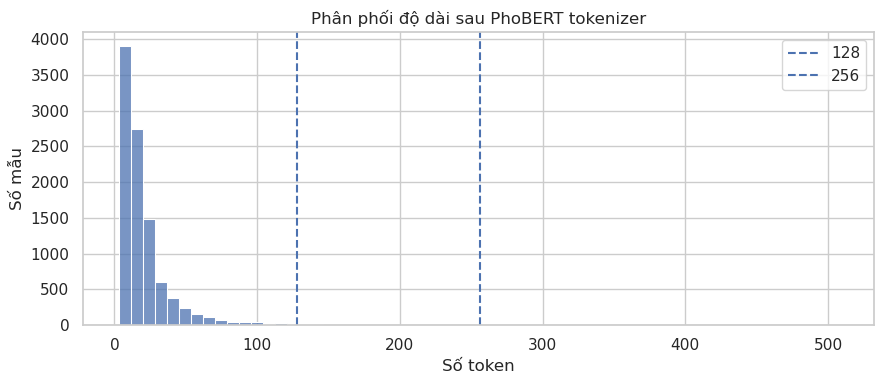

Gợi ý MAX_LEN: 128
Tỷ lệ mẫu bị truncation với MAX_LEN=128: 0.93%


In [17]:
MODEL_NAME = "vinai/phobert-base"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=False)

# Lấy mẫu từ train để ước lượng nhanh độ dài token.
# Nếu muốn đo chính xác toàn bộ train, đổi sample_size = len(train_df).
sample_size = min(10000, len(train_df))
sample_texts = train_df["text_phobert"].sample(
    sample_size,
    random_state=RANDOM_STATE
).tolist()

token_lengths = [
    len(tokenizer.encode(text, add_special_tokens=True))
    for text in sample_texts
]

token_len_series = pd.Series(token_lengths)

display(
    token_len_series
    .describe(percentiles=[0.5, 0.75, 0.90, 0.95, 0.99])
    .to_frame("token_length")
)

plt.figure(figsize=(9, 4))
sns.histplot(token_len_series, bins=60)
plt.axvline(128, linestyle="--", label="128")
plt.axvline(256, linestyle="--", label="256")
plt.title("Phân phối độ dài sau PhoBERT tokenizer")
plt.xlabel("Số token")
plt.ylabel("Số mẫu")
plt.legend()
plt.tight_layout()
plt.show()

recommended_max_len = 128 if token_len_series.quantile(0.95) <= 128 else 256
print("Gợi ý MAX_LEN:", recommended_max_len)

truncation_rate = (token_len_series > recommended_max_len).mean()
print(
    f"Tỷ lệ mẫu bị truncation với MAX_LEN={recommended_max_len}: "
    f"{truncation_rate:.2%}"
)

**Nhận xét**

Kết quả tokenization trên mẫu 10,000 văn bản từ tập train cho thấy độ dài sau PhoBERT tokenizer vẫn tương đối ngắn. Trung bình mỗi bình luận có khoảng 21.36 token, trung vị là 14 token. Có 75% mẫu không quá 24 token, 90% không quá 42 token và 95% không quá 61 token. Điều này cho thấy phần lớn bình luận có thể được biểu diễn đầy đủ với độ dài đầu vào tương đối nhỏ.

Phân phối token length tiếp tục có xu hướng lệch phải: đa số văn bản tập trung ở vùng dưới 50 token, trong khi chỉ một số ít mẫu có độ dài lớn hơn nhiều. Giá trị lớn nhất trong mẫu kiểm tra là 507 token, nhưng đây là các trường hợp ngoại lệ. Nếu chọn `MAX_LEN` theo giá trị lớn nhất, quá trình huấn luyện sẽ tốn nhiều bộ nhớ GPU do padding, trong khi lợi ích thu được không lớn.

Hai mốc 128 và 256 được đưa vào biểu đồ để so sánh các lựa chọn độ dài đầu vào phổ biến khi fine-tune Transformer. Với dữ liệu hiện tại, phân vị 99% chỉ khoảng 126 token và tỷ lệ văn bản vượt quá 128 token chỉ khoảng 0.93% trên mẫu kiểm tra. Vì vậy, `MAX_LEN = 128` là lựa chọn hợp lý để cân bằng giữa việc giữ nội dung văn bản và tiết kiệm tài nguyên huấn luyện.

## 10. Chuẩn bị DatasetDict cho fine-tuning PhoBERT

Sau khi có các tập dữ liệu cố định, bước cuối cùng là chuyển sang định dạng phù hợp với Hugging Face `Trainer`. Cột văn bản đầu vào là `text_phobert`, còn nhãn được đổi sang tên `labels` để tương thích với mô hình `AutoModelForSequenceClassification`.

In [18]:
MAX_LEN = recommended_max_len

dataset = DatasetDict({
    "train": Dataset.from_pandas(train_df[["text_phobert", "label"]].reset_index(drop=True)),
    "validation": Dataset.from_pandas(val_df[["text_phobert", "label"]].reset_index(drop=True)),
    "test": Dataset.from_pandas(test_df[["text_phobert", "label"]].reset_index(drop=True)),
})


def tokenize_batch(batch):
    return tokenizer(
        batch["text_phobert"],
        padding="max_length",
        truncation=True,
        max_length=MAX_LEN,
    )


encoded_dataset = dataset.map(tokenize_batch, batched=True)
encoded_dataset = encoded_dataset.rename_column("label", "labels")


try:
    import torch

    encoded_dataset.set_format(
        type="torch",
        columns=["input_ids", "attention_mask", "labels"]
    )
    print("Đã set format PyTorch cho fine-tuning.")
except ImportError:
    print(
        "Chưa cài PyTorch nên bỏ qua set_format(type='torch'). "
        "Dataset đã được tokenize. Khi fine-tune PhoBERT trên Colab/GPU, hãy chạy lại bước này."
    )

encoded_dataset

Map:   0%|          | 0/127536 [00:00<?, ? examples/s]

Map:   0%|          | 0/27329 [00:00<?, ? examples/s]

Map:   0%|          | 0/27330 [00:00<?, ? examples/s]

Chưa cài PyTorch nên bỏ qua set_format(type='torch'). Dataset đã được tokenize. Khi fine-tune PhoBERT trên Colab/GPU, hãy chạy lại bước này.


DatasetDict({
    train: Dataset({
        features: ['text_phobert', 'labels', 'input_ids', 'attention_mask'],
        num_rows: 127536
    })
    validation: Dataset({
        features: ['text_phobert', 'labels', 'input_ids', 'attention_mask'],
        num_rows: 27329
    })
    test: Dataset({
        features: ['text_phobert', 'labels', 'input_ids', 'attention_mask'],
        num_rows: 27330
    })
})

In [19]:
# Class weights có thể dùng trong loss nếu muốn giảm ảnh hưởng mất cân bằng nhẹ giữa các lớp.
classes = np.array(sorted(train_df["label"].unique()))
weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=train_df["label"].values,
)

class_weight_df = pd.DataFrame({
    "label": classes,
    "label_name": [label_map[int(c)] for c in classes],
    "class_weight": weights,
})
display(class_weight_df)

,label,label_name,class_weight
0,0,negative,1.066319
1,1,neutral,0.924435
2,2,positive,1.019937


**Nhận xét**

Dataset đã được chuyển sang định dạng `DatasetDict` của Hugging Face với ba tập `train`, `validation` và `test`. Sau bước tokenize, mỗi mẫu có thêm các trường `input_ids` và `attention_mask`, đồng thời cột nhãn được đổi từ `label` sang `labels` để tương thích với `AutoModelForSequenceClassification`.

Do môi trường local hiện tại chưa cài PyTorch, bước `set_format(type="torch")` được bỏ qua. Điều này không ảnh hưởng đến phần EDA và preprocessing, vì dữ liệu đã được tokenize đầy đủ. Khi chuyển sang fine-tune PhoBERT trên Colab hoặc môi trường có GPU, chỉ cần cài PyTorch và chạy lại bước set format hoặc để Hugging Face Trainer tự chuyển dữ liệu sang tensor.

Bảng class weight cho thấy dữ liệu sau khi chia tập chỉ mất cân bằng nhẹ. Lớp neutral có trọng số thấp hơn vì chiếm tỷ lệ cao nhất, trong khi lớp negative có trọng số cao hơn do số mẫu ít hơn. Các trọng số này có thể được dùng trong hàm loss nếu muốn giảm ảnh hưởng của mất cân bằng nhãn, nhưng không bắt buộc vì phân phối nhãn nhìn chung vẫn tương đối ổn định.

## 11. Tổng kết pipeline

Notebook đã xây dựng pipeline EDA và preprocessing phù hợp cho bài toán Vietnamese Sentiment Analysis với PhoBERT. Các bước chính gồm:

1. Chuẩn hóa cấu trúc dữ liệu với hai cột `text` và `label`.
2. Kiểm tra phân phối nhãn, missing, empty và duplicate.
3. Phân tích độ dài văn bản để định hướng chọn `MAX_LEN`.
4. Kiểm tra các dạng nhiễu phổ biến trong bình luận người dùng.
5. Làm sạch văn bản ở mức vừa đủ, không xóa các tín hiệu cảm xúc quan trọng.
6. Phân tích token, log-ratio và cụm từ sentiment ở mức vừa đủ để hiểu tín hiệu ngôn ngữ trong dữ liệu.
7. Thực hiện word segmentation để tạo đầu vào phù hợp với PhoBERT.
8. Loại duplicate sau preprocessing và chia train/validation/test theo stratify.
9. Kiểm tra độ dài bằng PhoBERT tokenizer.
10. Tạo `DatasetDict` sẵn sàng cho fine-tuning.

Sau notebook này, bước tiếp theo là fine-tune `vinai/phobert-base` hoặc `vinai/phobert-large` cho bài toán phân loại 3 lớp và đánh giá bằng Accuracy, Macro-F1, Precision, Recall và confusion matrix.